In [8]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

_CODES = Path("/home/aiia/newDisk/liyihua/2026_scs_relaxation/codes").resolve()
sys.path.insert(0, str(_CODES))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<unknown>:176: SyntaxWarning: invalid escape sequence '\d'
<unknown>:176: SyntaxWarning: invalid escape sequence '\d'
<unknown>:176: SyntaxWarning: invalid escape sequence '\d'
<unknown>:177: SyntaxWarning: invalid escape sequence '\d'
<unknown>:177: SyntaxWarning: invalid escape sequence '\d'
<unknown>:177: SyntaxWarning: invalid escape sequence '\d'
<unknown>:177: SyntaxWarning: invalid escape sequence '\d'
<unknown>:177: SyntaxWarning: invalid escape sequence '\d'
<unknown>:176: SyntaxWarning: invalid escape sequence '\d'
<unknown>:176: SyntaxWarning: invalid escape sequence '\d'
<unknown>:176: SyntaxWarning: invalid escape sequence '\d'
<unknown>:177: SyntaxWarning: invalid escape sequence '\d'
<unknown>:177: SyntaxWarning: invalid escape sequence '\d'
<unknown>:177: SyntaxWarning: invalid escape sequence '\d'
<unknown>:177: SyntaxWarning: invalid escape sequence '\d'
<unknown>:177: SyntaxWarning: invalid escape sequence '\d'


### PFSS + SCS 衔接与已知数值现象

**1. 源面附近的“突变”与大闭合环顶（|B|→0）**

- 当前 **`get_Brtp(..., method='harmonics')` 在 `r = Rcp`（`R_hat`）处从 PFSS（Alm/Blm）切到 SCS（glm/hlm）**，而 `R_hat=2.4` 与 PFSS 源面 **`R_pfss=2.5` 不一致**：在 **2.4–2.5 R☉** 区间已用 SCS 外推，而不是 PFSS 在源面上的真实场，等值面/切片上会出现 **“环带”状强度变化**。
- SCS 系数由 **低阶拟合**（`lmax_scs=10`，且 `get_alpha_beta_mat` 里写死 `lmax=10`）从 cusp 上的 PFSS 场反演，**无法** 还原 PFSS 中 `lmax_pfss` 的高频结构 → 在 **大闭合环顶**（`Br→0`，`|B|` 很小）处，**相对误差** 被放大，看起来就像 **强度分布突变**。
- **建议**（减轻突变）：令 **`R_hat = R_pfss`**（即 **`Rcp = Rs`**，衔接面与 PFSS 源面重合），或提高 **`lmax_scs`**（15–20）并保证与 PFSS 角向分辨率一致；必要时在 **`[Rcp−δ, Rcp+δ]`** 对两套场做 **径向加权混合**。

**2. 高处的“X 型”/无源场表象**

- 解析上 SCS 每一项为自由空间磁场，**单看 SCS 满足 ∇·B=0**；但 **极性 mask**（`Br<0` 处整体反号）在 **正负磁区边界** 引入 **面电流** 式的间断，**拼接场在 mask 边界上 ∇·B 可非零**。
- **PFSS|SCS 在 `r=Rcp` 的矢量一般不严格连续**（仅最小二乘拟合 cusp 上的采样）→ 在 VTK 上画流线时，会表现为 **非势场的拓扑**（类似 X 点上方结构）。
- **AMRVAC**：应用 **GLM 散度清理** 或由 **矢量势** 初始化；本 notebook 仅提供 **B** 网格，不保证离散 ∇·B=0。


In [2]:
from pfss.funcs import Spherical_Harmonics
from pfss.needs import *  
from pfss.scs_module import scs_solver,pfss_solver
from pfss.off_module import off_solver
from astropy import units as u
from astropy import constants as const

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, PowerNorm
import sunpy
import sunpy.visualization.colormaps as cm
from scipy.ndimage import zoom

import pfss
print(pfss.__file__)

/Users/zhaoyan/Documents/02_spherical_solar_wind/code_backup/MagWind-main/codes/pfss/__init__.py


In [3]:
fits_file = './magmaps/hmi.synoptic_mr_polfil_720s.2270.Mr_polfil.fits'

In [5]:
R_scs = 12.0
R_pfss = 2.6
R_hat  = 2.3

q = 1.005

nr = 500
nt = 96
nphi = 192

lmax_pfss = 10
lmax_scs = 20


In [6]:
# Geometric radial stretch (same as AMRVAC qstretch_baselevel)
R_min = 1.0
R_max = R_scs
dr0 = (R_max - R_min) * (q - 1) / (q**nr - 1)
r_edges = R_min + dr0 * (q**np.arange(nr + 1) - 1) / (q - 1)
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
dr = np.diff(r_edges)

dth = np.pi / nt
dph = 2 * np.pi / nphi
t_centers = np.linspace(dth / 2, np.pi - dth / 2, nt)
p_centers = np.linspace(dph / 2, 2 * np.pi - dph / 2, nphi)

rr, tt, pp = np.meshgrid(r_centers, t_centers, p_centers, indexing='ij')
rtp_grid = np.stack([rr, tt, pp])

print(f"Radial: nr={nr}, dr_min={dr.min():.6f}, dr_max={dr.max():.6f} R_sun")
print(f"  constant stretch ratio dr[i+1]/dr[i] = {q:.6f}")
print(f"Theta/phi: nt={nt}, nphi={nphi}, mesh shape (nr,nt,nphi)={rr.shape}")

Radial: nr=500, dr_min=0.004952, dr_max=0.059654 R_sun
  constant stretch ratio dr[i+1]/dr[i] = 1.005000
Theta/phi: nt=96, nphi=192, mesh shape (nr,nt,nphi)=(500, 96, 192)


In [9]:
import torch

# PFSS on uniform r grid (internal); Alm/Blm saved for harmonics evaluation on stretched mesh
ps = pfss_solver(
    fits_file,
    n_r=400,
    n_t=nt,
    n_p=nphi,
    lmax=lmax_pfss,
    Rs=R_pfss,
)

devices = ['cuda:0'] if torch.cuda.is_available() else ['cpu']
Brtp_pfss = ps.multi_gpu_pfss(
    devices,
    load_coef=False,
    save_coef=True,
    fast_mode=True,
)
print('PFSS done. Brtp shape (3, nr, nt, nphi):', Brtp_pfss.shape)
print('Alm.pkl / Blm.pkl should exist in the notebook working directory for harmonics.')

/Users/zhaoyan/Documents/02_spherical_solar_wind/code_backup/MagWind-main/codes/pfss/pfss_module.py:176: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xticklabels(['$90\degree$','$180\degree$','$270\degree$'])
/Users/zhaoyan/Documents/02_spherical_solar_wind/code_backup/MagWind-main/codes/pfss/pfss_module.py:176: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xticklabels(['$90\degree$','$180\degree$','$270\degree$'])
/Users/zhaoyan/Documents/02_spherical_solar_wind/code_backup/MagWind-main/codes/pfss/pfss_module.py:176: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xticklabels(['$90\degree$','$180\degree$','$270\degree$'])
/Users/zhaoyan/Documents/02_spherical_solar_wind/code_backup/MagWind-main/codes/pfss/pfss_module.py:177: SyntaxWarning: invalid escape sequence '\d'
  ax.set_yticklabels(['$-60\degree$', '$-30\degree$', '$0\degree$', '$30\degree$', '$60\degree$'])
/Users/zhaoyan/Documents/02_spherical_solar_wind/code_backup/MagWind-main/codes/pfss/pfss_module.py:1

KeyboardInterrupt: 

In [65]:
# SCS: glm/hlm from PFSS field at R_hat (cusp); uses same (nt, nphi) as PFSS boundary
ss = scs_solver(
    fits_file,
    n_r=400,
    n_t=nt,
    n_p=nphi,
    lmax=lmax_pfss,
    Rs=R_pfss,
    Rcp=R_hat,
    Rtp=R_scs,
    lmax_scs=lmax_scs,
    Nrtp_scs=[200, nt, nphi],
)
print('SCS initialized: glm/hlm fitted from PFSS at R_hat =', R_hat, 'R_sun')

SCS initialized: glm/hlm fitted from PFSS at R_hat = 2.45 R_sun


In [74]:
# Full domain on the same stretched grid
# split at R_pfss (default in scs_module): r <= R_pfss -> PFSS, r > R_pfss -> SCS
# smooth transition around split radius to reduce shell-to-shell jumps
interface_blend_half_width = 0.08  # in R_sun, try 0.03~0.08

device = 'cuda' if torch.cuda.is_available() else 'cpu'
rtp = np.stack([rr, tt, pp])
Brtp = ss.get_Brtp(
    rtp,
    method='harmonics',
    device=device,
    # optional: keep explicit split value; None defaults to ss.Rs
    sc_split_radius=2.5,
    interface_blend_half_width=interface_blend_half_width,
)
print('Brtp shape:', Brtp.shape)
print('Br min/max:', float(Brtp[0].min()), float(Brtp[0].max()))

out_npy = './Brtp_combined_lmax10_Rs_blend.npy'
np.save(out_npy, Brtp)
np.savez_compressed('./rtp_stretched.npz', rr=rr, tt=tt, pp=pp)
print('Saved', out_npy, 'and rtp_stretched.npz (rr, tt, pp for VTK export)')

Brtp shape: (3, 500, 96, 192)
Br min/max: -18.618304242271382 34.78520688798953
Saved ./Brtp_combined_lmax10_Rs_blend.npy and rtp_stretched.npz (rr, tt, pp for VTK export)


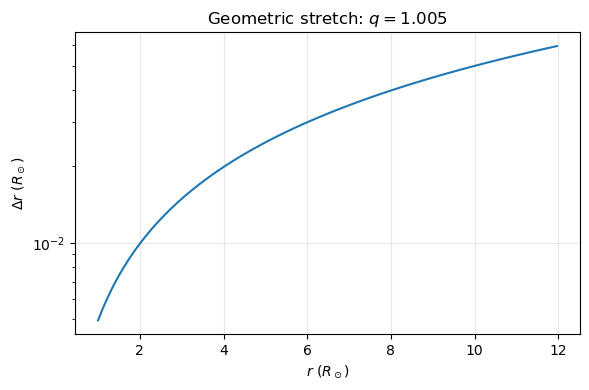

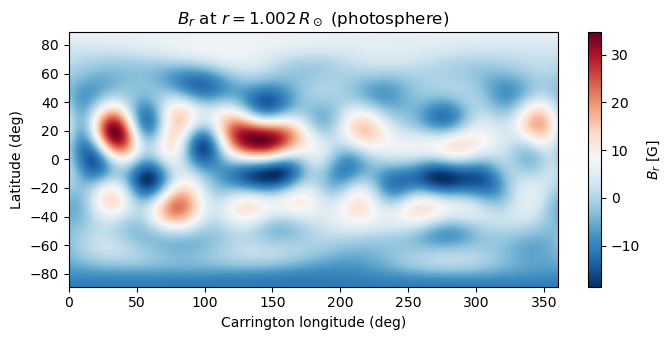

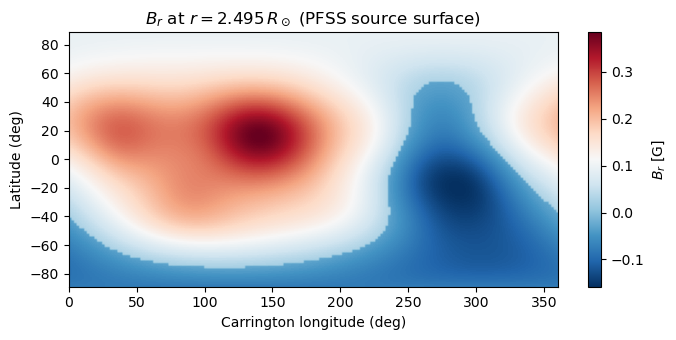

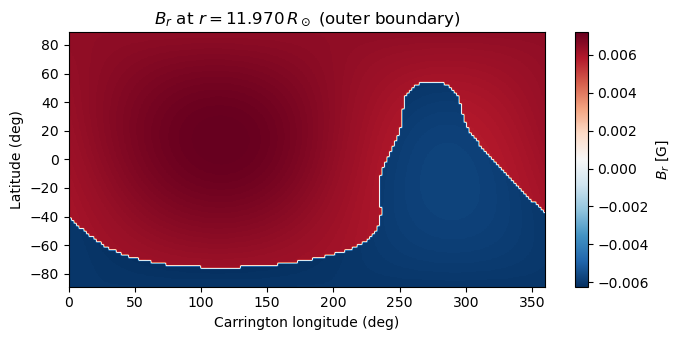

In [75]:
# Radial resolution dr(r)
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(r_centers, dr, color='C0')
ax.set_xlabel(r'$r$ ($R_\odot$)')
ax.set_ylabel(r'$\Delta r$ ($R_\odot$)')
ax.set_title(f'Geometric stretch: $q={q}$')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Br maps at r ~ 1, R_pfss, R_scs (nearest radial level)
lat_deg = 90.0 - np.degrees(t_centers)

def nearest_r_idx(r_target):
    return int(np.argmin(np.abs(r_centers - r_target)))

targets = [
    (1.0, 'photosphere'),
    (R_pfss, 'PFSS source surface'),
    (R_scs, 'outer boundary'),
]
for r_tar, label in targets:
    ir = nearest_r_idx(r_tar)
    Br_slice = Brtp[0, ir, :, :]
    fig, ax = plt.subplots(figsize=(7, 3.5))
    im = ax.imshow(
        Br_slice,
        origin='upper',
        aspect='auto',
        cmap='RdBu_r',
        extent=[0, 360, lat_deg.min(), lat_deg.max()],
    )
    ax.set_xlabel('Carrington longitude (deg)')
    ax.set_ylabel('Latitude (deg)')
    ax.set_title(rf'$B_r$ at $r={r_centers[ir]:.3f}\,R_\odot$ ({label})')
    plt.colorbar(im, ax=ax, label=r'$B_r$ [G]')
    plt.tight_layout()
    plt.show()

In [76]:
#Brtp = np.load('./Brtp_combined_lmax10_Rcs2.45.npy')
rtp = [rr, tt, pp]
Br = Brtp[0,:,:,:]
Bt = Brtp[1,:,:,:]
Bp = Brtp[2,:,:,:]

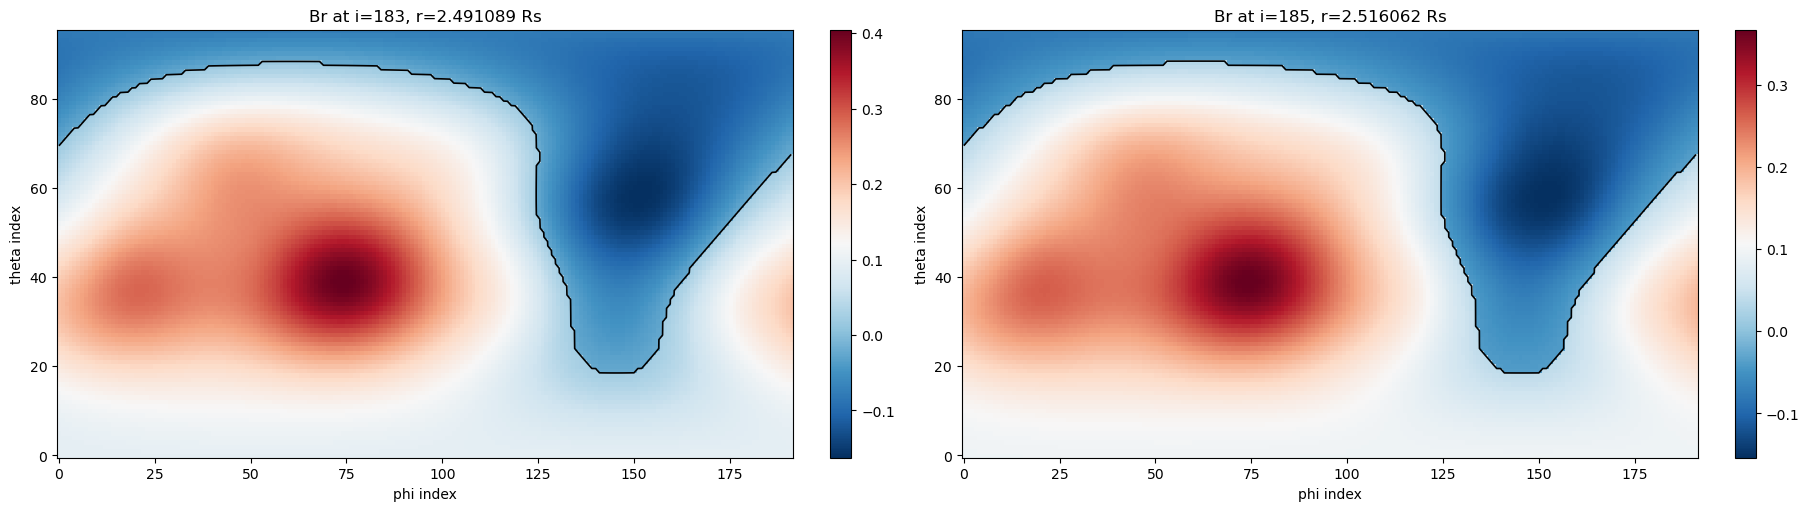

In [77]:
import matplotlib.pyplot as plt

q = 1.005
rmin = 1.0
r_indices = [183, 185]

fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)

for ax, i in zip(axes, r_indices):
    r_val = rmin * q**i

    im = ax.imshow(Br[i, :, :], cmap='RdBu_r', origin='lower', aspect='auto')
    ax.contour(Br[i,:,:], levels=[0.0], colors='k', linewidths=1.2)

    ax.set_title(f'Br at i={i}, r={r_val:.6f} Rs')
    ax.set_xlabel('phi index')
    ax.set_ylabel('theta index')
    fig.colorbar(im, ax=ax)

plt.show()


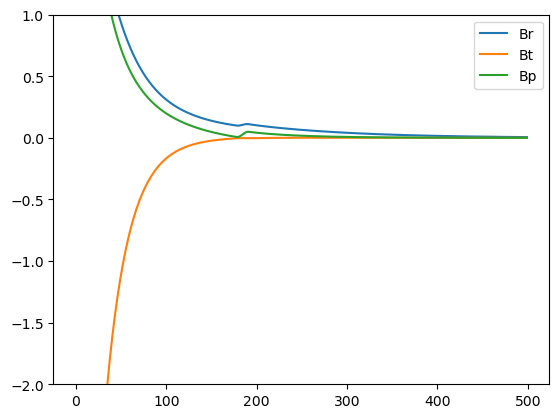

In [78]:
plt.plot(Br[:,30,120],label='Br')
plt.plot(Bt[:,30,120],label='Bt')
plt.plot(Bp[:,30,120],label='Bp')
plt.ylim(-2,1)
plt.legend()
plt.show()

In [30]:
# VTK export (needs pyevtk + vtk in kernel, e.g. zzsolar_rht)
from pfss.pfss_module import Brtp2vts

Brtp = np.load('./Brtp_combined_lmax10_Rcs2.45.npy')
rtp = [rr, tt, pp]
vts_name = f'Brtp_lmax10_Rcs2.45'
Brtp2vts(Brtp, rtp, vts_name=vts_name)
print(f'Saved {vts_name}.vts (structured; ParaView / VisIt)')

# .vtu 可用 Brtp2vtu，但对 ~10^7 点会极慢，一般只用 .vts
# from pfss.pfss_module import Brtp2vtu
# Brtp2vtu(Brtp, rtp, vtu_name=vts_name)

 Start to save .vts file... 


Time Used:    0.444 min...
Saved Brtp_lmax10_Rcs2.45.vts (structured; ParaView / VisIt)
